# DAY 2-2. Modeling : 모델 학습, 선택, 평가
DAY 1 설계(PDF 13장, 14장)를 그대로 구현한다.

**모델 선택 규칙**
1. Test(b2, b3)는 선택에 쓰지 않는다. 선택이 끝난 뒤 보고만 한다
2. 선택 대상 : 피처셋 A, B × 모델 7종. 셋 C는 가설 검증용 비교군이라 선택 대상에서 사전 제외
3. 기준 : (Train CV MAPE + Valid MAPE) / 2의 20 seed 평균이 최소
4. 1위와의 차이가 1위 기준값의 20 seed 표준편차보다 작은 후보 중에서는 피처 수가 적고 단순한 모델을 택한다

**지표** : log10 예측값을 역변환한 cycle life의 MAPE (%)

In [1]:
import json, os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import make_scorer
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True, 'grid.alpha': .3,
                     'axes.spines.top': False, 'axes.spines.right': False})
DATA, FIG = '../data', '../figures/model'; os.makedirs(FIG, exist_ok=True)
M = pd.read_csv(f'{DATA}/model_input.csv'); SETS = json.load(open(f'{DATA}/feature_sets.json'))
SPLITS = json.load(open(f'{DATA}/splits.json'))
TR, B2, B3, SEN = [M[M.role == r].reset_index(drop=True) for r in ['train', 'test', 'test_extra', 'sensitivity']]
TARGET_MAPE = 9.1
def mape(y_log, p_log):
    y, p = 10 ** np.asarray(y_log), 10 ** np.asarray(p_log)
    return float(np.mean(np.abs(p - y) / y) * 100)
SCORER = make_scorer(lambda y, p: -mape(y, p))
print(len(TR), len(B2), len(B3), len(SEN))

36 39 44 5


## 1. 후보 모델과 탐색 범위 (PDF 13장)
모든 모델은 `StandardScaler → 모델` Pipeline이라 CV fold마다 학습 fold로만 표준화한다.

In [2]:
MODELS = {   # name : (estimator, param grid, 복잡도 순위)
    'Linear':     (LinearRegression(), {}, 0),
    'Ridge':      (Ridge(), {'m__alpha': np.logspace(-3, 2, 11)}, 1),
    'Lasso':      (Lasso(max_iter=100000), {'m__alpha': np.logspace(-4, -0.5, 8)}, 1),
    'ElasticNet': (ElasticNet(max_iter=100000), {'m__alpha': np.logspace(-4, 0, 9), 'm__l1_ratio': [.1, .5, .9]}, 2),
    'GPR':        (GaussianProcessRegressor(ConstantKernel(1.0, (1e-2, 1e2)) * RBF(1.0, (1e-1, 1e2)) + WhiteKernel(1e-2, (1e-3, 1.0)),
                                            normalize_y=True, n_restarts_optimizer=3, random_state=0), {}, 3),
    'SVR':        (SVR(), {'m__C': [0.3, 1, 3, 10], 'm__gamma': ['scale', 0.1, 1], 'm__epsilon': [0.01, 0.03]}, 3),
    'RF':         (RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1), {'m__max_depth': [2, 3], 'm__min_samples_leaf': [2, 4]}, 4),
}
def tune(df, feats, name):
    est, grid, _ = MODELS[name]
    pipe = Pipeline([('s', StandardScaler()), ('m', clone(est))])
    k = min(5, df.policy.nunique())
    gs = GridSearchCV(pipe, grid or [{}], cv=GroupKFold(k), scoring=SCORER, n_jobs=-1)
    gs.fit(df[feats], df.log_life, groups=df.policy)
    return gs   # refit=True : 전체 df로 재학습된 best 모델
print({k: int(np.prod([len(v) for v in g.values()])) if g else 1 for k, (_, g, _) in MODELS.items()}, '개 조합')

{'Linear': 1, 'Ridge': 11, 'Lasso': 8, 'ElasticNet': 27, 'GPR': 1, 'SVR': 24, 'RF': 4} 개 조합


## 2. 20 seed × 피처셋 3 × 모델 7 = 420회 학습
seed마다 Batch 1을 Train(≈80%) / Valid(≈20%)로 나누고, Train 안에서 정책 단위 GroupKFold(5)로 하이퍼파라미터를 고른다.
- **Train MAPE** = 선택된 하이퍼파라미터의 GroupKFold CV 평균
- **Valid MAPE** = Train 전체로 재학습한 모델의 hold-out 성능

In [3]:
rows = []
key = TR.set_index('key')
for sp in SPLITS:
    tr, va = key.loc[sp['train']].reset_index(), key.loc[sp['valid']].reset_index()
    for s, feats in SETS.items():
        for name in MODELS:
            gs = tune(tr, feats, name)
            rows.append(dict(seed=sp['seed'], set=s, model=name, n_feat=len(feats), cv=-gs.best_score_,
                             valid=mape(va.log_life, gs.predict(va[feats])), params=str(gs.best_params_)))
R = pd.DataFrame(rows); R['score'] = (R.cv + R.valid) / 2
R.to_csv(f'{DATA}/model_runs_20seeds.csv', index=False)
S = R.groupby(['set', 'model']).agg(n_feat=('n_feat', 'first'), cv_mean=('cv', 'mean'), cv_std=('cv', 'std'),
                                    valid_mean=('valid', 'mean'), valid_std=('valid', 'std'),
                                    score_mean=('score', 'mean'), score_std=('score', 'std')).round(2)
S['cv_seed0'] = R[R.seed == 0].set_index(['set', 'model']).cv.round(2)
S['valid_seed0'] = R[R.seed == 0].set_index(['set', 'model']).valid.round(2)
S.sort_values('score_mean')

n_feat  cv_mean  cv_std  valid_mean  valid_std  score_mean  \
set model                                                                    
C   Linear           7     6.08    1.07        6.71       2.69        6.40   
    Ridge            7     6.04    1.08        7.35       4.21        6.70   
    ElasticNet       7     6.10    1.07        7.40       4.17        6.75   
    Lasso            7     6.41    1.08        7.60       4.56        7.00   
    GPR              7     8.61    1.95        7.71       3.52        8.16   
A   Linear           1     8.83    0.81        9.63       2.55        9.23   
    ElasticNet       1     8.80    0.76        9.75       2.41        9.28   
    Lasso            1     8.80    0.77        9.77       2.36        9.29   
    Ridge            1     8.79    0.76        9.78       2.38        9.29   
B   Lasso            2     8.94    0.84       10.22       3.28        9.58   
    ElasticNet       2     8.87    0.84       10.35       3.20        9.61   
C   SVR              7     9.41    0.96        9.90       3.40        9.65   
B   Linear           2     9.23    0.84       10.34       3.54        9.79   
    Ridge            2     9.18    0.83       10.68       3.41        9.93   
A   SVR              1     9.14    1.02       10.86       2.64       10.00   
    RF               1     9.52    0.91       10.90       3.32       10.21   
    GPR              1    10.31    1.51       10.89       3.05       10.60   
C   RF               7    10.27    0.90       11.41       3.26       10.84   
B   RF               2    10.19    1.09       11.64       2.94       10.91   
    SVR              2    11.17    1.10       13.30       4.29       12.24   
    GPR              2    11.94    1.17       13.33       4.86       12.63   

                score_std  cv_seed0  valid_seed0  
set model                                         
C   Linear           1.26      7.77         4.00  
    Ridge            1.94      7.80         6.94  
    ElasticNet       1.87      7.85         3.72  
    Lasso            2.00      8.13         3.50  
    GPR              1.45     10.52         5.83  
A   Linear           0.93      9.31         7.80  
    ElasticNet       0.89      9.31         7.80  
    Lasso            0.86      9.31         7.81  
    Ridge            0.88      9.31         7.80  
B   Lasso            1.39      9.84         8.95  
    ElasticNet       1.39      9.83         8.91  
C   SVR              1.60     10.88         6.58  
B   Linear           1.49     10.16         8.50  
    Ridge            1.44     10.16         8.50  
A   SVR              0.96      9.91         8.52  
    RF               1.39     10.23         6.47  
    GPR              1.40     12.55         8.21  
C   RF               1.49     10.97         6.25  
B   RF               1.23     11.70         6.80  
    SVR              1.80     11.72         9.02  
    GPR              2.09     12.69         9.30

## 3. 모델 선택 (규칙 ①\~④)

In [4]:
cand = S.loc[['A', 'B']].reset_index().sort_values('score_mean').reset_index(drop=True)
best = cand.iloc[0]
tol = best.score_std
near = cand[cand.score_mean - best.score_mean < tol].copy()
near['complexity'] = near.model.map({k: v[2] for k, v in MODELS.items()})
pick = near.sort_values(['n_feat', 'complexity', 'score_mean']).iloc[0]
print(f"1위 : 셋 {best.set} · {best.model}  score {best.score_mean:.2f} ± {best.score_std:.2f}")
print(f"1위와 차이 < {tol:.2f} 인 후보 :", [f'{r.set}·{r.model}' for _, r in near.iterrows()])
print(f"→ 선택 : 셋 {pick.set} · {pick.model} (피처 {pick.n_feat}개)")
SEL_SET, SEL_MODEL = pick.set, pick.model
cand.head(8)

1위 : 셋 A · Linear  score 9.23 ± 0.93
1위와 차이 < 0.93 인 후보 : ['A·Linear', 'A·ElasticNet', 'A·Lasso', 'A·Ridge', 'B·Lasso', 'B·ElasticNet', 'B·Linear', 'B·Ridge', 'A·SVR']
→ 선택 : 셋 A · Linear (피처 1개)


,set,model,n_feat,cv_mean,cv_std,valid_mean,valid_std,score_mean,score_std,cv_seed0,valid_seed0
0,A,Linear,1,8.83,0.81,9.63,2.55,9.23,0.93,9.31,7.80
1,A,ElasticNet,1,8.80,0.76,9.75,2.41,9.28,0.89,9.31,7.80
2,A,Lasso,1,8.80,0.77,9.77,2.36,9.29,0.86,9.31,7.81
3,A,Ridge,1,8.79,0.76,9.78,2.38,9.29,0.88,9.31,7.80
4,B,Lasso,2,8.94,0.84,10.22,3.28,9.58,1.39,9.84,8.95
5,B,ElasticNet,2,8.87,0.84,10.35,3.20,9.61,1.39,9.83,8.91
6,B,Linear,2,9.23,0.84,10.34,3.54,9.79,1.49,10.16,8.50
7,B,Ridge,2,9.18,0.83,10.68,3.41,9.93,1.44,10.16,8.50


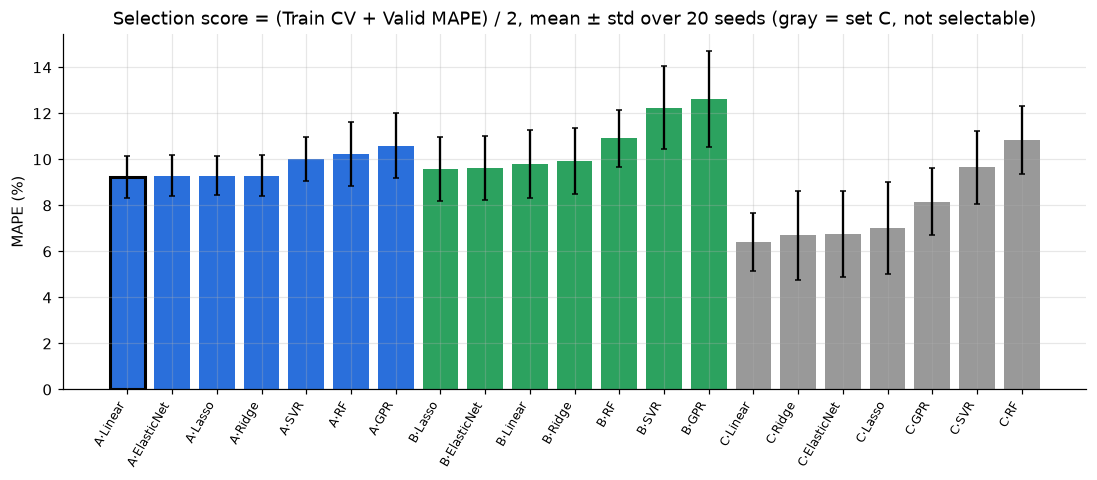

In [5]:
fig, ax = plt.subplots(figsize=(12, 4.2))
order = S.reset_index().sort_values(['set', 'score_mean'])
lab = order.set + '·' + order.model
col = order.set.map({'A': '#2a6fdb', 'B': '#2ca25f', 'C': '#999999'})
ax.bar(range(len(order)), order.score_mean, yerr=order.score_std, color=col, capsize=2)
ax.set_xticks(range(len(order))); ax.set_xticklabels(lab, rotation=60, ha='right', fontsize=8)
i = list(lab).index(f'{SEL_SET}·{SEL_MODEL}'); ax.bar(i, order.score_mean.iloc[i], color='none', edgecolor='k', lw=2)
ax.set(title='Selection score = (Train CV + Valid MAPE) / 2, mean ± std over 20 seeds (gray = set C, not selectable)',
       ylabel='MAPE (%)')
plt.savefig(f'{FIG}/model_selection.png', dpi=170, bbox_inches='tight'); plt.show()

## 4. 최종 학습과 Test
선택된 피처셋·모델로 **Batch 1 전체(36셀)** 에서 GroupKFold(5)로 하이퍼파라미터를 다시 고르고 재학습한 뒤 Batch 2, Batch 3를 예측한다.

In [6]:
feats = SETS[SEL_SET]
final = tune(TR, feats, SEL_MODEL)
print('최종 하이퍼파라미터 :', final.best_params_)
for d in (B2, B3): d['pred_log'] = final.predict(d[feats]); d['pred'] = 10 ** d.pred_log; d['err_pct'] = (d.pred - d.life) / d.life * 100
sel = S.loc[(SEL_SET, SEL_MODEL)]
test_b2, test_b3 = mape(B2.log_life, B2.pred_log), mape(B3.log_life, B3.pred_log)
REPORT = pd.DataFrame({
    'Train (b1 CV)': [sel.cv_mean, sel.cv_std, sel.cv_seed0],
    'Valid (b1 hold-out)': [sel.valid_mean, sel.valid_std, sel.valid_seed0],
    'Test (b2)': [test_b2, np.nan, np.nan]}, index=['MAPE % (20 seed 평균)', '표준편차', 'seed 0']).round(2)
GAP = pd.Series({'Gap (Train−Valid)': sel.valid_mean - sel.cv_mean, 'Gap (Valid−Test)': test_b2 - sel.valid_mean,
                 'Gap (Target−Test)': test_b2 - TARGET_MAPE}).round(2)
print(f'모델 : 셋 {SEL_SET} {feats} · {SEL_MODEL}')
display(REPORT); print(GAP.to_string())
print(f'\n[추가] Test (b3) MAPE = {test_b3:.2f}%, Gap (b2−b3) = {test_b3 - test_b2:+.2f}')
print('Gap 부호 : 양수 = 뒤 단계에서 오차 증가. Valid는 선택에 쓰였으므로 일반화 성능은 Test로 판단한다')

최종 하이퍼파라미터 : {}
모델 : 셋 A ['dQ_logvar'] · Linear


,Train (b1 CV),Valid (b1 hold-out),Test (b2)
MAPE % (20 seed 평균),8.83,9.63,28.56
표준편차,0.81,2.55,NaN
seed 0,9.31,7.80,NaN


Gap (Train−Valid)     0.80
Gap (Valid−Test)     18.93
Gap (Target−Test)    19.46

[추가] Test (b3) MAPE = 12.81%, Gap (b2−b3) = -15.75
Gap 부호 : 양수 = 뒤 단계에서 오차 증가. Valid는 선택에 쓰였으므로 일반화 성능은 Test로 판단한다


## 5. 잔차 분석 : 일반 / newstructure (PDF 5장, 14장)
오차가 무작위인지, 구조별로 한쪽으로 쏠린 편향인지 본다. `bias` = 평균 부호 오차 (+ = 과대예측).

,batch,group,n,MAPE,bias,life_median
0,b2,normal,30,31.9,31.9,451.0
1,b2,newstructure,9,17.5,15.7,904.0
2,b3,newstructure,44,12.8,1.6,1005.5


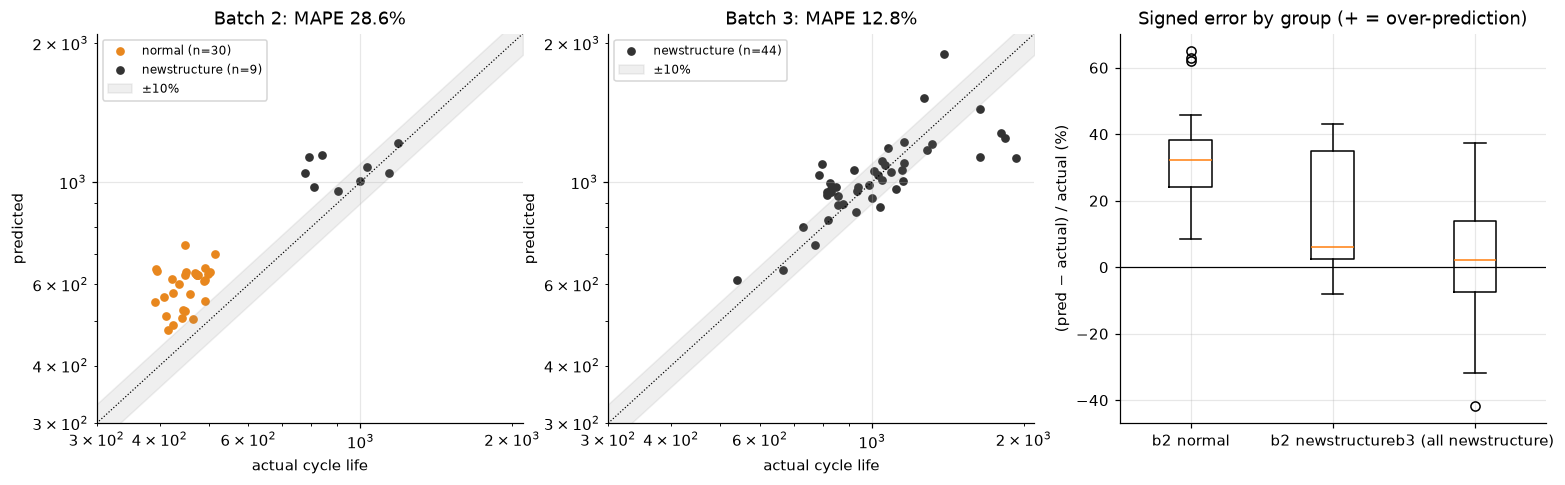

In [7]:
res = []
for name, d in (('b2', B2), ('b3', B3)):
    for ns, g in d.groupby('newstruct'):
        res.append(dict(batch=name, group='newstructure' if ns else 'normal', n=len(g),
                        MAPE=g.err_pct.abs().mean(), bias=g.err_pct.mean(), life_median=g.life.median()))
RES = pd.DataFrame(res).round(1); display(RES)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
lim = [300, 2100]
for a, (name, d) in zip(ax[:2], (('Batch 2', B2), ('Batch 3', B3))):
    for ns, c, lab in ((0, '#e8871e', 'normal'), (1, '#333', 'newstructure')):
        g = d[d.newstruct == ns]
        if len(g): a.scatter(g.life, g.pred, c=c, s=22, label=f'{lab} (n={len(g)})')
    a.plot(lim, lim, 'k:', lw=.8); a.fill_between(lim, [l * .9 for l in lim], [l * 1.1 for l in lim], color='gray', alpha=.12, label='±10%')
    a.set(xlim=lim, ylim=lim, xscale='log', yscale='log', title=f'{name}: MAPE {mape(d.log_life, d.pred_log):.1f}%',
          xlabel='actual cycle life', ylabel='predicted'); a.legend(fontsize=8)
data = [B2[B2.newstruct == 0].err_pct, B2[B2.newstruct == 1].err_pct, B3.err_pct]
ax[2].boxplot(data, tick_labels=['b2 normal', 'b2 newstructure', 'b3 (all newstructure)']); ax[2].axhline(0, c='k', lw=.8)
ax[2].set(title='Signed error by group (+ = over-prediction)', ylabel='(pred − actual) / actual (%)')
plt.savefig(f'{FIG}/test_pred_residual.png', dpi=170, bbox_inches='tight'); plt.show()

## 6. 가설 검증 · 민감도 · 불확실성 (선택이 끝난 뒤의 보고용)
- **셋 C 가설** : 배치 간 부호가 뒤집히는 피처를 넣으면 b2 성능이 떨어지는가 → 셋 A, B, C 각각의 최적 모델을 같은 방식으로 학습해 Test 비교
- **민감도** : b1 c0\~c4를 원논문 보정 수명으로 학습에 넣으면 어떻게 달라지는가
- **불확실성** : GPR 95% 예측 구간이 Test 셀을 얼마나 덮는가 (외삽 구간의 불확실성 표시)

In [8]:
hyp = []
for s in SETS:
    bm = S.loc[s].score_mean.idxmin(); m = tune(TR, SETS[s], bm)
    hyp.append(dict(set=s, model=bm, n_feat=len(SETS[s]), score_b1=S.loc[(s, bm)].score_mean,
                    test_b2=mape(B2.log_life, m.predict(B2[SETS[s]])), test_b3=mape(B3.log_life, m.predict(B3[SETS[s]]))))
HYP = pd.DataFrame(hyp).round(2); display(HYP)

TRS = pd.concat([TR, SEN], ignore_index=True)
ms = tune(TRS, feats, SEL_MODEL)
SENS = pd.DataFrame({'train cells': [len(TR), len(TRS)], 'life range': [f'{TR.life.min():.0f}~{TR.life.max():.0f}', f'{TRS.life.min():.0f}~{TRS.life.max():.0f}'],
                     'Test (b2)': [test_b2, mape(B2.log_life, ms.predict(B2[feats]))],
                     'Test (b3)': [test_b3, mape(B3.log_life, ms.predict(B3[feats]))]},
                    index=['기본 (c0~c4 제외)', '민감도 (c0~c4 보정 수명 포함)']).round(2)
display(SENS)

gp = tune(TR, feats, 'GPR').best_estimator_
cov = {}
for name, d in (('b2', B2), ('b3', B3)):
    mu, sd = gp.predict(d[feats], return_std=True)
    cov[name] = dict(coverage_95=float(np.mean(np.abs(d.log_life - mu) <= 1.96 * sd) * 100), mean_interval_x=float(np.mean(10 ** (1.96 * sd))))
print('GPR 95% 예측 구간 :', {k: {kk: round(vv, 2) for kk, vv in v.items()} for k, v in cov.items()})

,set,model,n_feat,score_b1,test_b2,test_b3
0,A,Linear,1,9.23,28.56,12.81
1,B,Lasso,2,9.58,32.07,12.40
2,C,Linear,7,6.40,101.96,58.40


,train cells,life range,Test (b2),Test (b3)
기본 (c0~c4 제외),36,534~1074,28.56,12.81
민감도 (c0~c4 보정 수명 포함),41,534~2237,26.17,15.26


GPR 95% 예측 구간 : {'b2': {'coverage_95': 41.03, 'mean_interval_x': 1.26}, 'b3': {'coverage_95': 84.09, 'mean_interval_x': 1.29}}


## 6-2. 오류 분석 : 가장 크게 틀린 셀 · 절편 재보정 (`src/train.py`와 같은 계산)
- 오차 상위 12셀이 어떤 셀인지(배치, 구조, 학습 수명 범위 안/밖) 확인한다
- **(추가 분석)** 새 배치에서 수명이 확인된 셀 k개로 절편만 보정했을 때 나머지 셀의 MAPE. 테스트 배치의 실제 수명 일부를 쓰는 운영 시나리오라 위 성능표와 분리해서 보고한다

In [9]:
T = pd.concat([B2, B3], ignore_index=True); T['batch'] = ['b2'] * len(B2) + ['b3'] * len(B3)
lo, hi = TR.life.min(), TR.life.max()
T['life_vs_b1'] = np.where(T.life < lo, 'b1 최소 미만', np.where(T.life > hi, 'b1 최대 초과', 'b1 범위 안'))
top = T.reindex(T.err_pct.abs().sort_values(ascending=False).index).head(12)
display(top[['batch', 'key', 'policy', 'newstruct', 'life', 'pred', 'err_pct', 'life_vs_b1', 'dQ_logvar']].round(2))
print(f'상위 12셀 중 b2 일반 구조 : {((top.batch == "b2") & (top.newstruct == 0)).sum()}셀 | b1 수명 범위({lo:.0f}~{hi:.0f}) 밖 : {(top.life_vs_b1 != "b1 범위 안").sum()}셀')
print('오차–실제 수명 상관 : b2 {:.2f}, b3 {:.2f} (짧은 셀은 과대, 긴 셀은 과소 예측)'.format(
      np.corrcoef(B2.err_pct, B2.life)[0, 1], np.corrcoef(B3.err_pct, B3.life)[0, 1]))

def offset_calibration(d, ks=(1, 3, 5, 10), n_draw=500, seed=0):
    rng = np.random.default_rng(seed); y, p = d.log_life.values, d.pred_log.values; rows = []
    for k in ks:
        m = []
        for _ in range(n_draw):
            idx = rng.choice(len(y), k, replace=False); rest = np.setdiff1d(np.arange(len(y)), idx)
            m.append(mape(y[rest], p[rest] + np.mean(y[idx] - p[idx])))
        rows.append(dict(k_cells=k, mape_mean=np.mean(m), mape_std=np.std(m)))
    return pd.DataFrame(rows)
CAL = pd.concat([offset_calibration(d).assign(batch=b) for b, d in (('b2', B2), ('b3', B3))]).round(2)
print(f'절편 재보정 전 : b2 {test_b2:.2f}%, b3 {test_b3:.2f}%'); display(CAL.pivot(index='k_cells', columns='batch', values='mape_mean'))

,batch,key,policy,newstruct,life,pred,err_pct,life_vs_b1,dQ_logvar
6,b2,b2c6,3.6C(9%)-5C,0,393.0,648.19,64.93,b1 최소 미만,-3.53
18,b2,b2c18,5.2C(50%)-4.25C,0,449.0,731.81,62.99,b1 최소 미만,-3.71
15,b2,b2c15,3.6C(9%)-5C,0,396.0,642.11,62.15,b1 최소 미만,-3.52
2,b2,b2c2,5.2C(50%)-4.25C,0,424.0,617.96,45.75,b1 최소 미만,-3.46
9,b2,b2c9,5.6C(26%)-4.5C-newstructure,1,791.0,1131.83,43.09,b1 범위 안,-4.34
75,b3,b3c38,5C(67%)-4C-newstructure,1,1935.0,1129.99,-41.60,b1 최대 초과,-4.34
27,b2,b2c29,5.2C(58%)-4C,0,452.0,638.60,41.28,b1 최소 미만,-3.51
19,b2,b2c19,6C(60%)-3C,0,392.0,550.73,40.49,b1 최소 미만,-3.29
11,b2,b2c11,5.2C(50%)-4.25C,0,449.0,628.69,40.02,b1 최소 미만,-3.49
21,b2,b2c21,6C(60%)-3C,0,408.0,563.97,38.23,b1 최소 미만,-3.33


상위 12셀 중 b2 일반 구조 : 9셀 | b1 수명 범위(534~1074) 밖 : 10셀
오차–실제 수명 상관 : b2 -0.56, b3 -0.67 (짧은 셀은 과대, 긴 셀은 과소 예측)
절편 재보정 전 : b2 28.56%, b3 12.81%


batch,b2,b3
k_cells,,
1,14.93,19.84
3,12.27,15.99
5,11.46,14.55
10,10.92,13.61


## 7. 결과 저장

In [10]:
out = dict(selected=dict(set=SEL_SET, features=feats, model=SEL_MODEL, params=str(final.best_params_)),
           report=REPORT.to_dict(), gap=GAP.to_dict(), test_b3=test_b3, residual=RES.to_dict('records'),
           hypothesis_setC=HYP.to_dict('records'), sensitivity=SENS.reset_index().to_dict('records'), gpr_coverage=cov,
           summary=S.reset_index().to_dict('records'))
def _clean(o):   # NaN → null (표준 JSON)
    if isinstance(o, dict): return {k: _clean(v) for k, v in o.items()}
    if isinstance(o, list): return [_clean(v) for v in o]
    if isinstance(o, (float, np.floating)): return None if np.isnan(o) else float(o)
    if isinstance(o, np.integer): return int(o)
    return o
json.dump(_clean(out), open(f'{DATA}/model_report.json', 'w'), ensure_ascii=False, indent=1, allow_nan=False, default=str)
pd.concat([B2.assign(batch='b2'), B3.assign(batch='b3')])[['batch', 'key', 'policy', 'newstruct', 'life', 'pred', 'err_pct']] \
  .round(2).to_csv(f'{DATA}/test_predictions.csv', index=False)
print('saved : model_report.json, test_predictions.csv, model_runs_20seeds.csv')

saved : model_report.json, test_predictions.csv, model_runs_20seeds.csv


## 8. 결과 해석 요약 (자세한 내용은 README)
| 발견 | 해석 | DAY 1 근거 |
|---|---|---|
| Test b2 28.6%, b2 일반 셀 30셀 전부 과대예측 (bias +31.9%) | 무작위 오차가 아닌 배치 수준(절편) 차이 | 8장 : 같은 dQ_logvar에서 b2 수명 약 22% 짧음 |
| Test b3 12.8%, bias +1.6% | ΔQ 신호의 기울기는 배치를 넘어 유지 | 8장 : 배치별 기울기 −0.30 / −0.33 / −0.31 |
| 셋 C : Batch 1 기준 6.4%로 1위지만 b2 102% | 배치마다 부호가 뒤집히는 피처는 테스트에서 무너짐 | 10장 : b1 강한 피처 8개 중 4개가 b2에서 반전 |
| c0\~c4 포함 시 b2 28.6 → 26.2% | b2 오차의 주원인은 학습 수명 범위가 아니라 배치 효과 | 3장 : 보정 수명 검증 불가, 민감도로만 사용 |
| GPR 95% 구간이 b2를 41%만 덮음 | 배치가 바뀌면 불확실성 과소평가 | 15장 리스크 ① 외삽 |

**ESS 관점** : 새 로트·사이트에 적용할 때는 소수 셀의 초기 데이터로 절편을 재보정해야 한다. 과대예측은 교체 지연 쪽 오류라 운영상 더 위험하다.

**한계** : 학습 36셀·정책 20개로 Valid 분산이 크고(±2.55), Valid는 선택에 쓰여 약간 낙관적이다. 학습 배치에 newstructure와 b2·b3 로트가 없어 배치 효과를 학습할 수 없다.